# T3 · Gravity — where the law is exact

The first of three physics domains, in rising order of how badly the law can
let you down. Here it cannot: Kepler's third law

$$P = 2\pi\sqrt{a^3 / GM}$$

is exact for a two-body system, and the only unknown is `GM`. This is the
**best case** for a physics prior, and it is worth seeing what that best case
actually buys — which is less than you might expect.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

from physprior.problems.gravity import kepler
from physprior.benchmark.protocol import fit_arm, split_random
from physprior.io import load_table
prob, meta = kepler.problem()
print(f"track: {prob.track},  {len(prob)} planets,  recovering {[p.name for p in prob.params]}")
print(f"published GM_sun = {meta['published_GM_sun']:.6e} m^3/s^2")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


track: gravity/kepler,  8 planets,  recovering ['GM']
published GM_sun = 1.327124e+20 m^3/s^2


## Five arms on the same data

Every track in this repository is run through the same five arms, so that
"physics-informed" is compared against something rather than asserted:

| arm | knows the law? | returns a constant? |
|---|---|---|
| `oracle` | published law **and** published constant — the ceiling, not a competitor | — |
| `physics` | the law, constants fitted by `curve_fit` | yes, with a covariance |
| `pinn` | `y = law(x; θ) + σ_y·NN(x)` — law plus a learned correction | yes |
| `sr` | **no** — symbolic regression searches for a law | sometimes |
| `nn` | no — a tuned MLP | no |

In [2]:
idx = np.arange(len(prob))
for arm in ("oracle", "physics", "pinn", "nn"):
    fit = fit_arm(arm, prob, idx, seed=11)
    gm = fit.params.get("GM")
    err = "" if gm is None else f"   GM error {abs(gm - meta['published_GM_sun'])/meta['published_GM_sun']*1e6:8.1f} ppm"
    print(f"{arm:8s} {fit.expression or 'no closed form':52s}{err}")

oracle   P = 2*pi*sqrt(a**3/(G*M))                              GM error      0.0 ppm
physics  P = 2*pi*sqrt(a**3/(G*M))                              GM error     59.3 ppm


pinn     P = 2*pi*sqrt(a**3/(G*M))  + NN(x)                     GM error     59.3 ppm


nn       no closed form                                      


## The PINN here is a *correction*, not a solver

Note the shape of the `pinn` arm. It is not solving a differential equation
as in T1 — it is

$$y = \text{law}(x;\theta) + \sigma_y\,\mathrm{NN}(x)$$

with the physical constant $\theta$ trainable, and a loss that penalises the
size of the correction:

$$\mathcal{L} = \frac{\mathrm{MSE}}{\sigma_y^2} + w_{\text{phys}}\,\overline{\mathrm{NN}^2}$$

That makes `w_phys` a **continuous dial between two named methods**: at
$w_{\text{phys}}\to\infty$ the correction is crushed and the arm *is* the
classical fit; at $w_{\text{phys}}=0$ it is a black box wearing a physics hat.

Both forms are PINNs. Which one you want depends on whether your law is an
algebraic relation (this) or a differential equation (T1, and T4).

In [3]:
sweep = load_table("gravity/kepler", "sweep_physics_weight")
g = sweep.groupby("w_phys")[["nrmse_out", "err_GM_pct"]].median()
print(g.to_string(float_format=lambda v: f"{v:.5g}"))

          nrmse_out  err_GM_pct
w_phys                         
0.000     0.0046516     -19.472
0.001    4.3252e-05   0.0055759
0.010    5.1927e-05   0.0055789
0.100    5.2962e-05   0.0055691
1.000    5.6843e-05   0.0055748
10.000    4.246e-05   0.0055741
1000.000 2.2381e-05   0.0056231


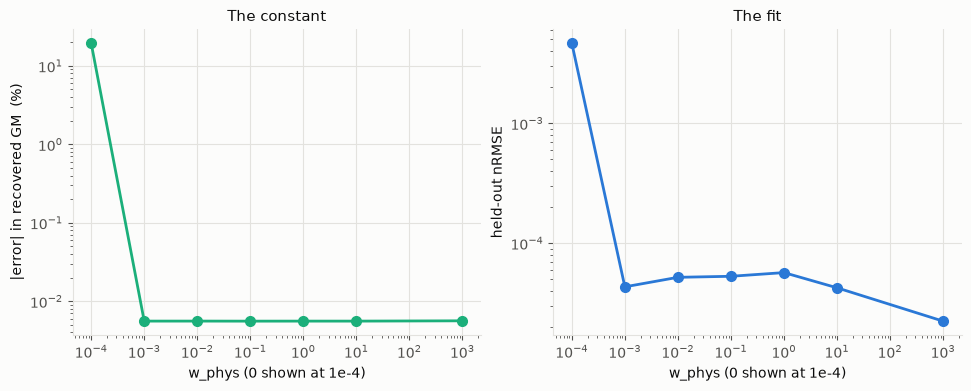

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))
axes[0].semilogx([max(w, 1e-4) for w in g.index], g.err_GM_pct.abs(), "-o",
                 color=P.ARM_COLOR["pinn"])
axes[0].set_yscale("log"); axes[0].set_xlabel("w_phys (0 shown at 1e-4)")
axes[0].set_ylabel("|error| in recovered GM  (%)")
axes[0].set_title("The constant")
axes[1].semilogx([max(w, 1e-4) for w in g.index], g.nrmse_out, "-o",
                 color=P.ARM_COLOR["physics"])
axes[1].set_yscale("log"); axes[1].set_xlabel("w_phys (0 shown at 1e-4)")
axes[1].set_ylabel("held-out nRMSE"); axes[1].set_title("The fit")
plt.show()

## The finding, on real data

The left panel falls off a cliff between `w_phys = 0` and `0.01`; the right
panel barely moves. **The held-out error cannot tell you whether your
recovered constant is any good.**

That is the same lesson as T2, now on eight real planets from the JPL DE441
ephemeris rather than a toy.

### What the physics prior buys here

With the law exact and the data clean, remarkably little in-distribution —
a tuned black box is competitive inside the training range. The prior earns
its place *outside* it, and in returning a number a physicist can argue with.

See [`docs/gravity/`](../../docs/gravity) for the track in full. Next:
[T4](T4_relativity.ipynb), where the law stops being exact.